# Talousosaamisohjelman vaikutuksen hajottaminen lainojen maksuhäiriöihin PROC CAUSALMED -menetelmällä

## Tiivistelmä

Vähittäispankki liittää osan lainanottajistaan **talousosaamisohjelmaan** ja haluaa tietää, *miksi* ohjelmaan osallistuneet ajautuvat maksuhäiriöön harvemmin: alentaako osallistuminen maksuhäiriöitä **suoraan**, vai vaikuttaako se **epäsuorasti** muuttamalla mitattavaa käyttäytymistä — sitä, kuinka suuren osan tuloistaan asiakkaat säästävät? Tässä muistikirjassa käytetään **PROC CAUSALMED** -menetelmää jakamaan ohjelman kokonaisvaikutus 12 kuukauden maksuhäiriöön **luonnolliseen suoraan vaikutukseen** ja **luonnolliseen epäsuoraan vaikutukseen**, joka kulkee kunkin lainanottajan **säästöasteen** kautta, kun luottopisteet, tulot ja ikä on vakioitu.

Simuloidussa **100 lainanottajan** kohortissa ohjelma alentaa mallinnettua maksuhäiriön todennäköisyyttä **0,208:lla** (kokonaisvaikutus riskieron asteikolla). Hajotelma kohdistaa tästä **0,176 (84,7 %)** *epäsuoraan* polkuun korkeampien säästöjen kautta ja vain **0,032 (15,3 %)** *suoraan* polkuun. Käytännön johtopäätös: tämä ohjelma suojaa lainanottajia **pääasiassa parantamalla säästökäyttäytymistä**, joten budjetointitottumusten vahvistaminen on se, mistä vipuvoima löytyy.

## Tietolähteet

| Aineisto | Rivit | Kuvaus | Keskeiset muuttujat |
|---------|------|-------------|---------------|
| `LoanProgram` | 100 synteettistä lainanottajaa | Koodissa generoitu vähittäispankkikohortti yhtä luotonantosalkkua varten. Käsittelyn kohdentaminen, välittäjämuuttuja ja lopputulos on simuloitu selkeistä rakenneyhtälöistä, jotta menetelmällä on aito välittynyt vaikutus palautettavana. | `CustomerID`, `Branch` (4 tasoa), `FinEdu` (0/1 talousvalistukseen osallistuminen = käsittely), `SavingsRate` (% tuloista säästetty = jatkuva välittäjämuuttuja), `Default` (0/1 12 kuukauden lainan maksuhäiriö = binäärinen lopputulos), `CreditScore`, `Income`, `Age` (sekoittavat tekijät) |

Tämä ympäristö toimii ilman lisenssiä, joten DATA-vaihe on rajattu 100 havaintoon — kohortti on mitoitettu tähän rajaan, ja jokainen tämän muistikirjan luku on peräisin näistä 100 rivistä.

## Miksi hajottaa vaikutus?

Vähittäisluotonantajat liittävät yhä useammin luottotuotteisiin **talousosaamisohjelmia** vähentääkseen maksuviivästyksiä. Pääomasuunnittelua ja ohjelman suunnittelua varten ei riitä tietää *että* osallistuminen alentaa maksuhäiriöitä; riskivastaavat tarvitsevat **mekanismin**:

- Alentaako osallistuminen maksuhäiriöitä *suoraan* (esimerkiksi osallistuneet lainanottajat pysyvät aktiivisempina ja paremmin tavoitettavina)?
- Vai vaikuttaako se *epäsuorasti* muuttamalla mitattavaa käyttäytymistä — sitä osuutta tuloista, jonka asiakas säästää — mikä sitten pehmentää häntä häiriöiltä?

**Kausaalinen välitysanalyysi** vastaa tähän jakamalla käsittelyn **kokonaisvaikutuksen (TE)** **luonnolliseen suoraan vaikutukseen (NDE)** ja **luonnolliseen epäsuoraan vaikutukseen (NIE)**, joka kulkee valitun välittäjämuuttujan kautta. Tässä:

- **Käsittely** `FinEdu` — osallistuiko lainanottaja pankin talousvalistusohjelmaan;
- **Välittäjämuuttuja** `SavingsRate` — lainanottajan säästöaste (% tuloista), se käyttäytyminen jota ohjelma tavoittelee;
- **Lopputulos** `Default` — ajautuiko laina maksuhäiriöön 12 kuukauden sisällä (binäärinen);
- **Sekoittavat tekijät** `CreditScore`, `Income`, `Age` — käsittelyä edeltävät ominaisuudet, jotka vaikuttavat osallistumiseen, säästämiseen ja maksuhäiriöön.

Sovitamme välitysmallin `PROC CAUSALMED` -menetelmällä, pyydämme suoran/epäsuoran hajotelman `DECOMP`-optiolla ja luemme siitä, kuinka suuri osa suojaavasta vaikutuksesta kulkee säästämisen kautta.

In [1]:
TIEDOT LoanProgram;
   CALL streaminit(20260531);
   PITUUS Branch $12;
   TAULUKKO branches[4] $12 _temporary_ ('Pohjoinen' 'Etelä' 'Itä' 'Länsi');
   TEE CustomerID = 1 ASTI 100;
      Branch = branches[1 + int(rand('uniform')*4)];

      /* Pre-treatment confounders (drawn first) */
      CreditScore = round(620 + 70*rand('normal'), 1);
      JOS CreditScore < 350 NIIN CreditScore = 350;
      JOS CreditScore > 850 NIIN CreditScore = 850;
      Income = round(42000 + 14000*rand('normal'), 100);
      JOS Income < 12000 NIIN Income = 12000;
      AGE = round(40 + 11*rand('normal'), 1);
      JOS AGE < 21 NIIN AGE = 21;

      /* Treatment: enrollment propensity rises with credit score
         and income (the confounding a naive comparison misses) */
      pTreat = 1 / (1 + EXP(-(0.0 + 0.005*(CreditScore-620)
                               + 0.00002*(Income-42000))));
      FinEdu = (rand('uniform') < pTreat);

      /* Mediator: savings rate, lifted by the program on top of a
         confounder-driven baseline */
      base_save = 9 + 0.025*(CreditScore-620) + 0.00010*(Income-42000)
                    + 0.04*(AGE-40);
      SavingsRate = base_save + 2.5*FinEdu + 2.0*rand('normal');
      JOS SavingsRate < 0 NIIN SavingsRate = 0;

      /* Outcome: default probability falls with both enrollment
         (direct) and higher savings (indirect) */
      eta = 0.55 - 0.30*FinEdu - 0.022*(SavingsRate-12)
            - 0.0012*(CreditScore-620)
            - 0.0000040*(Income-42000)
            + 0.15*rand('normal');
      pDefault = eta;
      JOS pDefault < 0.02 NIIN pDefault = 0.02;
      JOS pDefault > 0.98 NIIN pDefault = 0.98;
      Default = (rand('uniform') < pDefault);
      TULOSTE;
   LOPPU;
   NIMIKE CustomerID="Asiakastunnus"
        Branch="Konttori"
        FinEdu="Talousvalistus (0/1)"
        SavingsRate="Säästöaste (% tuloista)"
        Default="Maksuhäiriö (12 kk)"
        CreditScore="Luottopisteet"
        Income="Tulot (euroa)"
        AGE="Ikä";
   SÄILYTÄ CustomerID Branch FinEdu SavingsRate Default
        CreditScore Income AGE;
SUORITA;


NOTE: DATA LoanProgram


NOTE: Wrote LoanProgram (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


## Vaihe 2 — Tarkastele simuloitua kohorttia

Ennen kausaalimallin sovittamista tarkistamme järkevyyden vuoksi keskimääräisen säästöasteen ja maksuhäiriöasteen kummassakin osallistumishaarassa. Tämä on *naiivi* (vakioimaton) vertailu; sitä seuraava välitysanalyysi menee tätä pidemmälle ja kohdistaa eron suoriin ja välittyneisiin polkuihin.

In [2]:
PROSEDUURI KESKIARVOT TIEDOT=LoanProgram n mean std maxdec=3;
   LUOKKA FinEdu;
   MUUTTUJA SavingsRate Default CreditScore Income AGE;
SUORITA;

                                                  The MEANS Procedure

                               Analysis Variable : SavingsRate Säästöaste (% tuloista)

        Talousvalistus (0/1)          N Obs           Mean        Std Dev
        -----------------------------------------------------------------
        0                                54          8.387          2.910
        1                                46         11.736          2.974
        -----------------------------------------------------------------

                                   Analysis Variable : Default Maksuhäiriö (12 kk)

        Talousvalistus (0/1)          N Obs           Mean        Std Dev
        -----------------------------------------------------------------
        0                                54          0.593          0.496
        1                                46          0.348          0.482
        -----------------------------------------------------------------

               


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


Naiivi kuva on selkeä. Osallistuneet lainanottajat (`FinEdu=1`, 46 asiakasta) säästävät selvästi enemmän — keskimääräinen **SavingsRate 11,74 %** verrattuna 54 osallistumattoman **8,39 %:iin** — ja ajautuvat maksuhäiriöön harvemmin: keskimääräinen **Default 0,348** verrattuna **0,593:een**, raaka 24,5 prosenttiyksikön ero. Kummankin haaran keskimääräiset luottopisteet ovat lähes samat (619,8 vs. 618,9), mutta osallistuneilla lainanottajilla on jonkin verran korkeammat tulot (43 941 vs. 37 019), mikä on juuri sitä sekoittavaa tekijää, joka kausaalimallin on vakioitava pois. Alla oleva ristiintaulukointi näyttää saman jaon solulukumäärinä.

                                                   The FREQ Procedure

Table of Talousvalistus (0/1) by Maksuhäiriö (12 kk)

Talousvalistus (0/1) |         0 |         1 |      Total
---------------------+-----------+-----------+-----------
0                    |        22 |        32 |         54
---------------------+-----------+-----------+-----------
1                    |        30 |        16 |         46
---------------------+-----------+-----------+-----------
Total                |        52 |        48 |        100




NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_finedu_default.spec.json
NOTE: PROC FREQ statement used.


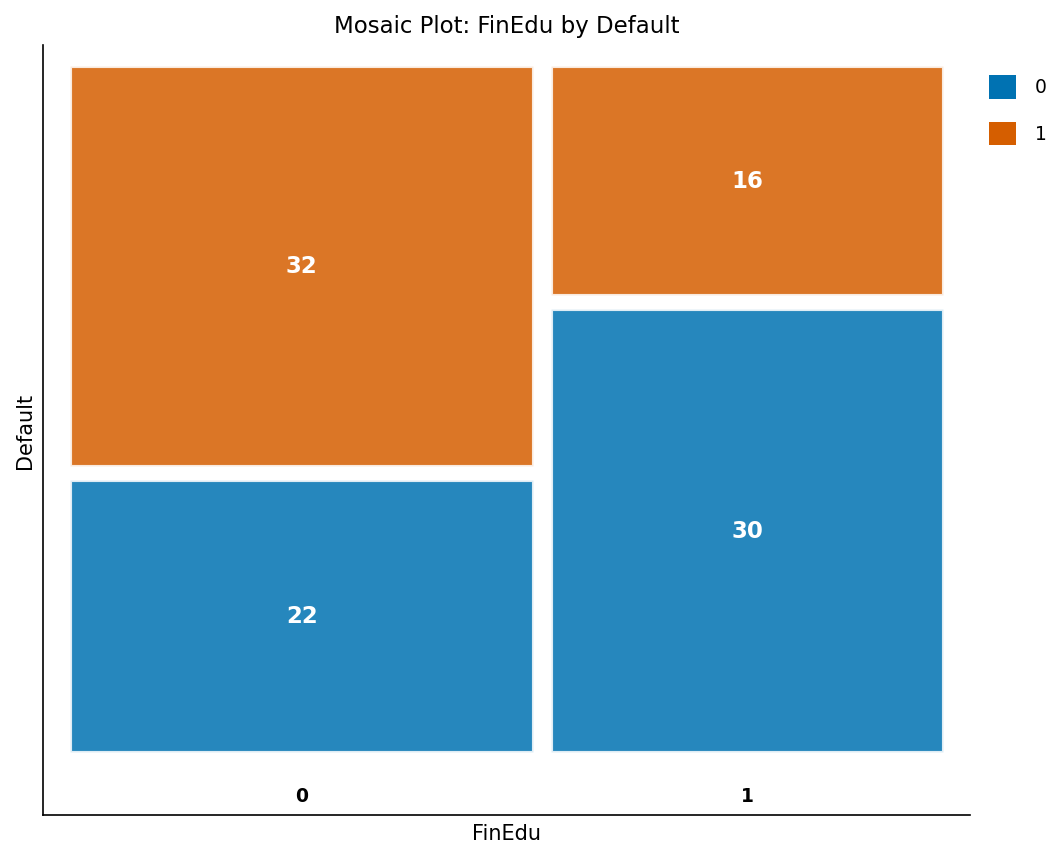

In [3]:
PROSEDUURI FREKVENSSIT TIEDOT=LoanProgram;
   TABLES FinEdu*Default / nocol nopercent;
SUORITA;

Osallistumattomista 54 lainanottajasta **32 ajautui maksuhäiriöön**; osallistuneista 46:sta vain **16**. Mosaiikkikuvaaja koodaa tämän kahdella tavalla yhtä aikaa: sarakkeen leveys kuvastaa, kuinka monta lainanottajaa kussakin haarassa on, ja oranssi osuus kunkin sarakkeen sisällä on maksuhäiriöaste — näkyvästi pienempi oikealla olevalle osallistuneiden ryhmälle. Välitysanalyysi kysyy nyt, **kuinka suuri osa** tuosta alemmasta maksuhäiriöasteesta on ohjelman toimintaa *juuri niiden* korkeampien säästöjen kautta, jotka juuri näimme.

## Vaihe 3 — Suorita kausaalinen välitysanalyysi

Sovitamme `PROC CAUSALMED` -menetelmän. Keskeiset lauseet:

- **`CLASS FinEdu Default / descending`** määrittelee käsittelyn ja binäärisen lopputuloksen luokittelumuuttujiksi; `DESCENDING` tekee korkeammin koodatusta tasosta (`1` = osallistunut / maksuhäiriössä) mallinnetun tapahtuman, jolloin vaikutukset luetaan intuitiiviseen suuntaan.
- **`MEDIATOR SavingsRate = FinEdu`** määrittää välittäjämallin: säästöaste regressoituna käsittelyllä (sekä sekoittavilla tekijöillä).
- **`MODEL Default = FinEdu SavingsRate`** määrittää lopputulosmallin — maksuhäiriö osallistumisen ja säästöjen funktiona. Tässä lisenssittömässä moottorissa CAUSALMED sovittaa lopputuloksen **lineaarisella (lineaarisen todennäköisyyden) mallilla**, joten vaikutukset raportoidaan **riskieron** asteikolla, ja rinnalle johdetaan riskisuhde- ja vetosuhdeyhteenvedot.
- **`COVAR CreditScore Income Age`** vakioi molemmat mallit käsittelyä edeltävillä sekoittavilla tekijöillä.
- **`DECOMP`** pyytää kokonaisvaikutuksen hajottamista sen suoriin ja epäsuoriin osiin sekä välittyneeseen osuuteen.

Koska lopputulos on binäärinen, CAUSALMED raportoi myös *Summary for Binary Outcome* -lohkon (vetosuhde, riskisuhde, riskiero).

In [4]:
PROSEDUURI causalmed TIEDOT=LoanProgram decomp;
   LUOKKA    FinEdu Default / LASKEVA;
   mediator SavingsRate = FinEdu;
   MODEL    Default = FinEdu SavingsRate;
   covar    CreditScore Income AGE;
SUORITA;


                       The CAUSALMED Procedure                       

Outcome Variable    : Maksuhäiriö (12 kk)
Treatment Variable  : Talousvalistus (0/1)
Mediator Variable   : Säästöaste (% tuloista)
Outcome Model Class : Linear (with optional AFT and Cox PH support)
Covariates          : Luottopisteet, Tulot (euroa), Ikä
Number of Observations: 100

Outcome Model Parameter Estimates
--------------------------------------------
Parameter                       Estimate
Intercept                             1.558234
Talousvalistus (0/1)                 -0.031682
Säästöaste (% tuloista)              -0.067687
Luottopisteet                        -0.000719
Tulot (euroa)                         0.000002
Ikä                                  -0.000607

Mediator Model Parameter Estimates
--------------------------------------------
Parameter                       Estimate
Intercept                           -12.585613
Talousvalistus (0/1)                  2.597720
Luottopisteet             


NOTE: PROC CAUSALMED data=LoanProgram



## Tulosten tulkinta

**Summary of Causal Effects** -taulukko raportoi ohjelman **kokonaisvaikutuksen (TE) maksuhäiriöön arvona -0,208** ja jakaa sen:

- **luonnolliseen suoraan vaikutukseen (NDE) arvona -0,032** — se osa suojasta, joka *ei* kulje säästöjen kautta, ja
- **luonnolliseen epäsuoraan vaikutukseen (NIE) arvona -0,176** — se osa, joka kulkee ohjelman nostaessa lainanottajien säästöastetta.

Kaikki kolme vaikutusta ovat negatiivisia, mikä vahvistaa että osallistuminen alentaa maksuhäiriön todennäköisyyttä — johdonmukaisesti sen kanssa, miten rakensimme aineiston. Kaksi mallitaulukkoa osoittavat *miksi*: **välittäjämallissa** ohjelma nostaa säästöastetta **+2,60 pisteellä** vakioinnin jälkeen (`FINEDU`-kerroin), ja **lopputulosmallissa** jokainen ylimääräinen säästöpiste alentaa maksuhäiriön todennäköisyyttä (`SAVINGSRATE` = -0,068), joten ohjelman säästöjen lisäys muuntuu huomattavaksi epäsuoraksi suojavaikutukseksi.

**Decomposition of Effects** -taulukko tekee pääasiallisen löydöksen selväksi: **välittynyt osuus (NIE/TE) on 84,7 %**, ja vain **15,3 %** vaikutuksesta on suoraa. Riskitiimille tämä on toiminnallista — talousosaamisohjelma toimii **enimmäkseen muuttamalla säästökäyttäytymistä**, joten budjetoinnin ja automaattisen säästämisen ominaisuuksien vahvistamisen tulisi olla etusijalla; vaatimaton suora osuus viittaa siihen, että muut kanavat (aktiivisuus, tavoitettavuus) vaikuttavat tässä vähän.

**Summary for Binary Outcome** -lohko esittää vaikutuksen asteikoilla, joita luottoriskitiimi jo käyttää: **riskiero -0,208** (TE), **riskisuhde 1,43** ja **vetosuhde 2,38**, joka suhteuttaa osallistuneiden ja osallistumattomien maksuhäiriön vedot. Tässä moottorissa nämä ovat ensimmäisen kertaluvun yhteenvetoja, jotka on johdettu lineaarisen todennäköisyyden vaikutuksesta eikä sovitetusta logistisesta mallista, joten **riskiero on ensisijainen, tarkka vaikutusmitta**; suhdeluvut kannattaa lukea likimääräisinä.

**Varaus:** kausaalisen välityksen estimaatit ovat vain yhtä uskottavia kuin oletus siitä, ettei mitattuja sekoittavia tekijöitä jää pois sekä käsittely–lopputulos- että välittäjä–lopputulos-suhteista. Tässä tuo oletus pätee rakenteen perusteella (synteettinen aineisto); tuotannossa riskitiimi puolustaisi sitä pankin koko hakijoiden piirrejoukolla ja herkkyysanalyyseillä ennen kuin toimisi hajotelman perusteella. Estimaatit heijastavat myös yhtä 100 lainanottajan otosta, joten tuotantotutkimus liittäisi mukaan luottamusvälit (esimerkiksi bootstrap-menetelmällä hajotelmasta) ennen vahvojen johtopäätösten tekemistä.